# 05 — LTCMA targeting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/05_ltcma_targeting.ipynb)

Complete workflow of the paper on four asset classes: a synthetic history
simulated from a C-vine with known families, J.P. Morgan's 2024 assumptions as
targets, the families selected back, the vine calibrated, scenarios simulated;
the Fleishman generator on the same targets; the exceedance-correlation curves
of the three series compared.

Runtime: 3 to 4 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import Targets, CVineMarket, FleishmanMarket, CVineGenerator

cvinemarketgen 0.2.0


## Targets and synthetic history

The J.P. Morgan table gives, for each of the $N = 4$ asset classes, the arithmetic mean $\mu_i$, the volatility $\sigma_i$ and the correlation matrix $\Sigma^*$, all annual. It gives no skewness or kurtosis, so a history is needed for them, and here the history is synthetic: it is simulated from a C-vine whose families and parameters are chosen, so that the selection step can be checked against a known truth.

The synthetic market is built in the order of the paper. The dictionary `edges` gives, for every pair $(i, k)$ with $k < i$, the copula $C_{ik \mid 1:k-1}$ of tree $k$: a family, a rotation and a parameter $\theta$, or a two-component mixture $C = w\,C_1 + (1 - w)\,C_2$. The marginals are Johnson SU, $X_i = \mu_i + \sigma_i\, q_i(Z)$ with $q_i(z) = \xi_i + \lambda_i \sinh\!\big((z - \gamma_i)/\delta_i\big)$ and the four parameters $(\gamma_i, \xi_i, \delta_i, \lambda_i)$ given in `jsu`. `simulate_known_vine` draws $n = 3000$ rows: independent uniforms $w_1, \dots, w_N$, the nested inverse $h$-functions of the C-vine (Section 4.5.1 of the paper) turn them into dependent uniforms $(U_1, \dots, U_N)$ with copula $C$, and $X_i = \mu_i + \sigma_i\, q_i(\Phi^{-1}(U_i))$ gives the returns, with $\mu_i, \sigma_i$ from the table.

`Targets.from_ltcma` then assembles the targets: $\mu_i$, $\sigma_i$ and $\Sigma^*$ from the table, and the skewness $\gamma_{1,i}$ and kurtosis $\gamma_{2,i}$ (raw, normal $= 3$) as the sample moments of the synthetic history. `true_edge_table` prints the edges that were used, the truth the next cell tries to recover.

In [2]:
assets = ["U.S. Large Cap", "U.S. Long Treasuries", "Commodities", "Gold"]
table = pd.read_csv(os.path.join(ROOT, "data", "jpm_ltcma_2024.csv"), index_col="Assets").loc[assets]
engine = CVineGenerator(tol_opt=1e-10, n_samples=10000, use_ncs_on_deepertrees=False, use_ncs_on_firsttree=False,
                        use_mixture_on_firsttree=True, use_mixture_on_deepertrees=False, force_try_ncscopula=False,
                        tol_for_optimization_func=1e-6)
edges = {(2, 1): ("mixture", [("clayton", 270, 0.66), ("gumbel", 0, 1.84)], 0.70),
         (3, 1): ("gumbel", 180, 1.38), (4, 1): ("gaussian", 0, 0.05),
         (3, 2): ("gaussian", 0, -0.15), (4, 2): ("gaussian", 0, 0.30), (4, 3): ("gaussian", 0, 0.20)}
jsu = {"U.S. Large Cap": (2.570, 2.179, 3.540, 2.646), "U.S. Long Treasuries": (-0.096, -0.095, 2.279, 2.062),
       "Commodities": (0.611, 0.589, 2.092, 1.774), "Gold": (-0.523, -0.516, 2.893, 2.675)}
hist = engine.simulate_known_vine(engine.make_vine_spec(assets, edges), jsu, table["Arithmetic Mean"], table["Volatility"], assets, n=3000, seed=1)
t = Targets.from_ltcma(table, assets=assets, history=hist)
engine.true_edge_table(assets, edges)

,tree,edge,true family,true parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",clayton 270° + gumbel 0°,"w=0.7, theta=(0.66, 1.84)"
1,1,"Commodities , U.S. Large Cap",gumbel 180°,theta=1.38
2,1,"Gold , U.S. Large Cap",gaussian 0°,theta=0.05
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.15
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.3
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.2


## C-vine generator: select, calibrate, simulate

`fit` runs the first three algorithms of the paper on the targets, with U.S. Large Cap as the central node of the C-vine.

1. Marginals: for each asset, the Johnson SU parameters solve the four moment equations so that $q_i(Z)$ has mean $0$, variance $1$, skewness $\gamma_{1,i}$ and kurtosis $\gamma_{2,i}$ (Section 4.3), by Nelder-Mead on the squared mismatch of the moments.
2. Family selection (Section 4.5.4): for every pair, the exceedance correlation $\hat\rho(z)$ is the Pearson correlation of the pair on the subsample where the central variable is below $z$ (for $z < 0$) or above $z$ (for $z \ge 0$), $z$ in standard deviations. Its shape gives a signature $(\ell, u, s, m)$: $\ell = 1$ if the dependence is stronger on the left, $u = 1$ if stronger on the right, $s = \mathrm{sign}(\Sigma^*_{ik})$, $m = -1$ if the curve changes sign. Among the families whose tail-dependence coefficients $\lambda_L = \lim_{u \to 0} C(u,u)/u$ and $\lambda_U = \lim_{u \to 1} (1 - 2u + C(u,u))/(1 - u)$ match the signature, the one with the lowest BIC on the history is kept; when $m = -1$ a mixture is admissible.
3. Calibration (Section 4.5.2): with the families fixed, the parameters are set variable by variable so that the simulated Pearson correlations hit the targets,

   $$
   \hat{\boldsymbol\theta}_i = \arg\min_{\boldsymbol\theta_i} \sum_{k < i} \Big( \mathrm{Corr}\big(F_i^{-1}(u_i(\boldsymbol\theta_i)),\, F_k^{-1}(u_k)\big) - \Sigma^*_{ik} \Big)^2, \qquad i = 2, \dots, N,
   $$

   on a fixed set of simulated uniforms, $F_i^{-1}(u) = \mu_i + \sigma_i\, q_i(\Phi^{-1}(u))$.

`edges` lists, per edge, the selected family, its rotation and the calibrated parameters; compare it with the true table above.

In [3]:
t0 = time.time()
cv = CVineMarket(t, central="U.S. Large Cap", families="auto").fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.edges

fit: 205 s


,tree,edge,selected family,parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",clayton 270° + gumbel 0°,"w=0.72, theta=(0.638, 1.939)"
1,1,"Commodities , U.S. Large Cap",gumbel 180°,theta=1.381
2,1,"Gold , U.S. Large Cap",clayton 180° + gumbel 90°,"w=0.20, theta=(0.602, 1.021)"
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.201
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.314
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.521


`simulate` is Algorithm 5 of the paper (Section 4.5.3). A draw of $n = 25{,}000$ uniform vectors comes from the calibrated vine; the Johnson SU parameters are re-fitted on that draw so that the sample moments of $q_i(\Phi^{-1}(U_i))$ match the targets exactly rather than in expectation; the scenarios are $X_i = \mu_i + \sigma_i\, q_i(\Phi^{-1}(U_i))$. The draw is accepted when

$$
|\hat\mu_i - \mu_i| \le 2 \times 10^{-4}, \quad |\hat\sigma_i - \sigma_i| \le 2 \times 10^{-4}, \quad |\hat\gamma_{1,i} - \gamma_{1,i}| \le 5 \times 10^{-2}, \quad |\hat\gamma_{2,i} - \gamma_{2,i}| \le 5 \times 10^{-2}, \quad |\hat\Sigma_{ik} - \Sigma^*_{ik}| \le \tau
$$

for every asset and pair, with $\tau$ the correlation tolerance (`corr_tol`, 0.05 here), and redrawn otherwise. `diagnostics` prints, per moment, the target, the simulated value and their difference, and the maximum and mean absolute entry of $\hat\Sigma - \Sigma^*$.

In [4]:
X = cv.simulate(25000, seed=1)
cv.diagnostics(X).summary();

25000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819       -0.0      0.1619         0.1619       0.0      -0.5091         -0.5091       -0.0       3.5815          3.5818     0.0004
U.S. Long Treasuries       0.0592          0.0592       -0.0      0.1239         0.1239       0.0       0.0987          0.0987        0.0       3.7461          3.7465     0.0004
Commodities                0.0531          0.0531        0.0      0.1800         0.1800       0.0      -0.5302         -0.5303       -0.0       4.3178          4.3183     0.0005
Gold                       0.0543          0.0543       -0.0      0.1693         0.1693       0.0       0.0928          0.0928        0.0       3.3657          3.3660     0.0003

max |diff| per moment: mean 1.6e-08, vol 3.6e-06, skew 3.2e-05, 

## Fleishman generator on the same targets

The Fleishman generator (Section 3 of the paper) uses the cubic transform $X_i = \mu_i + \sigma_i\,(a_i + b_i Z_i + c_i Z_i^2 + d_i Z_i^3)$, $Z_i \sim N(0, 1)$, with $(a_i, b_i, c_i, d_i)$ solving the three moment equations for mean $0$, variance $1$ and the target skewness and kurtosis (a solution exists only when $\gamma_{2,i} - 3 \ge \gamma_{1,i}^2 - 2$). Dependence is Gaussian: the normals $Z$ are correlated with the Vale-Maurelli intermediate correlation $\rho_Z$, the root in $[-1, 1]$ of

$$
\Sigma^*_{ik} = \rho_Z\,(b_i b_k + 3 b_i d_k + 3 d_i b_k + 9 d_i d_k) + 2\,\rho_Z^2\, c_i c_k + 6\,\rho_Z^3\, d_i d_k ,
$$

one pair at a time; the matrix of the $\rho_Z$ is projected onto the nearest positive-definite matrix and its Cholesky factor generates $Z$. The same acceptance test as above applies (correlation tolerance $2 \times 10^{-2}$ by default). The moments match; what a Gaussian copula cannot produce is tail dependence, which the next cell shows.

In [5]:
fm = FleishmanMarket(t).fit()
Xf = fm.simulate(25000, seed=1)
fm.diagnostics(Xf).summary();

25000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819        0.0      0.1619         0.1619       0.0      -0.5091         -0.5091       -0.0       3.5815          3.5818     0.0004
U.S. Long Treasuries       0.0592          0.0592        0.0      0.1239         0.1239       0.0       0.0987          0.0987        0.0       3.7461          3.7465     0.0004
Commodities                0.0531          0.0531       -0.0      0.1800         0.1800       0.0      -0.5302         -0.5303       -0.0       4.3178          4.3183     0.0005
Gold                       0.0543          0.0543       -0.0      0.1693         0.1693       0.0       0.0928          0.0928        0.0       3.3657          3.3660     0.0003

max |diff| per moment: mean 2.9e-16, vol 3.6e-06, skew 3.2e-05, 

## Exceedance correlation: history, C-vine, Fleishman

The C-vine reproduces the shape of the history, the sign change on the
Treasuries pair included; the Fleishman curves are flat.

For a threshold $z$ in standard deviations of the central variable $X_1$, the exceedance correlation is

$$
\hat\rho(z) = \begin{cases} \mathrm{Corr}\big(X_1, X_i \,\big|\, (X_1 - \bar X_1)/s_1 \le z\big) & z < 0, \\ \mathrm{Corr}\big(X_1, X_i \,\big|\, (X_1 - \bar X_1)/s_1 \ge z\big) & z \ge 0, \end{cases}
$$

computed on the subsample selected by the condition, for $z$ on a grid from $-1$ to $1$ by $0.05$. A copula with lower-tail dependence gives $\hat\rho(z)$ larger on the left than on the right; a mixture with components of opposite sign gives a curve that changes sign at some $z$; a Gaussian copula gives a curve that is symmetric and falls toward zero on both sides (the correlation of a truncated bivariate normal shrinks with truncation). The three curves are the synthetic history, the C-vine draw and the Fleishman draw, at the same target correlation.

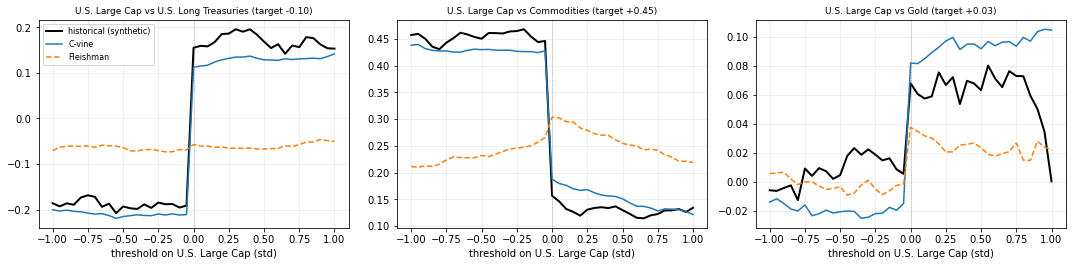

In [6]:
from cvinemarketgen import exceedance_curve
z = np.round(np.arange(-1, 1.001, 0.05), 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, a in zip(axes, assets[1:]):
    for name, df, st in [("historical (synthetic)", hist, dict(color="black", lw=2)), ("C-vine", X, dict(color="tab:blue")), ("Fleishman", Xf, dict(color="tab:orange", ls="--"))]:
        ax.plot(z, exceedance_curve(df["U.S. Large Cap"], df[a], z).values, label=name, **st)
    ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_title(f"U.S. Large Cap vs {a} (target {t.corr.loc['U.S. Large Cap', a]:+.2f})", fontsize=9)
    ax.set_xlabel("threshold on U.S. Large Cap (std)"); ax.grid(alpha=0.25)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## Reading the results

Both generators match the four moments (the marginals are re-fitted on the
accepted draw) and the correlations within tolerance. Only the C-vine
reproduces the tail dependence: the jump at zero on the equity-like pairs and
the sign change on the Treasuries pair, which comes from the mixture copula.